# Amazon Product Reviews — Sentiment Analysis
### SVM + SMOTE + VADER + Phrase Features | Full Pipeline with Model Persistence

**Dataset:** Amazon Reviews (train.csv / test.csv)
**Target:** `sentiment` — 1 = Negative · 2 = Positive
**Features:** `title` (product title) + `review` (review text)
**Source:** [Kaggle — Amazon Reviews](https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, json, pickle, warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("stopwords",    quiet=True)
nltk.download("vader_lexicon",quiet=True)
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score, learning_curve)
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, classification_report,
                             roc_auc_score, roc_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud

os.makedirs("Models", exist_ok=True)
vader = SentimentIntensityAnalyzer()
print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 1. Load & Explore Data

In [ ]:
train_df = pd.read_csv("amazon/amazon_review_polarity_csv/amazon_review_polarity_csv/train.csv", header=None)
train_df.columns = ["sentiment","title","review"]
print(f"Train shape: {train_df.shape}")
train_df.head()

Train shape: (3600000, 3)


,sentiment,title,review
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [3]:
test_df = pd.read_csv("test.csv", header=None)
test_df.columns = ["sentiment","title","review"]
print(f"Test shape: {test_df.shape}")
test_df.head()

Test shape: (400000, 3)


,sentiment,title,review
0,2,Great CD,My lovely Pat has one of the GREAT voices of h...
1,2,One of the best game music soundtracks - for a...,Despite the fact that I have only played a sma...
2,1,Batteries died within a year ...,I bought this charger in Jul 2003 and it worke...
3,2,"works fine, but Maha Energy is better",Check out Maha Energy's website. Their Powerex...
4,2,Great for the non-audiophile,Reviewed quite a bit of the combo players and ...


In [4]:
# Sample 20k train rows for manageable compute (original can be 3M+)
train_df = train_df.sample(20000, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(5000,  random_state=42).reset_index(drop=True)

print(f"Working train size : {train_df.shape}")
print(f"Working test size  : {test_df.shape}")
print(f"\nSentiment mapping  : 1 = Negative | 2 = Positive")
print(f"\nTrain dtypes:\n{train_df.dtypes}")

Working train size : (20000, 3)
Working test size  : (5000, 3)

Sentiment mapping  : 1 = Negative | 2 = Positive

Train dtypes:
sentiment     int64
title        object
review       object
dtype: object


### 1.1 Missing Values

In [5]:
print("=== TRAIN null counts ===")
print(train_df.isnull().sum())
print()
print("=== TEST null counts ===")
print(test_df.isnull().sum())

=== TRAIN null counts ===
sentiment    0
title        2
review       0
dtype: int64

=== TEST null counts ===
sentiment    0
title        0
review       0
dtype: int64


In [6]:
# Fill null titles; review nulls become empty string
for df in [train_df, test_df]:
    df["title"]  = df["title"].fillna("No Title")
    df["review"] = df["review"].fillna("")

# Combine title + review for richer text signal
train_df["full_text"] = train_df["title"].str.strip() + " " + train_df["review"].str.strip()
test_df["full_text"]  = test_df["title"].str.strip()  + " " + test_df["review"].str.strip()

print("Null check after fill:")
print(train_df.isnull().sum())

Null check after fill:
sentiment    0
title        0
review       0
full_text    0
dtype: int64


### 1.2 Sentiment Distribution

Sentiment counts:
sentiment
1     9973
2    10027
Name: count, dtype: int64
Positive %: 50.1%
Negative %: 49.9%


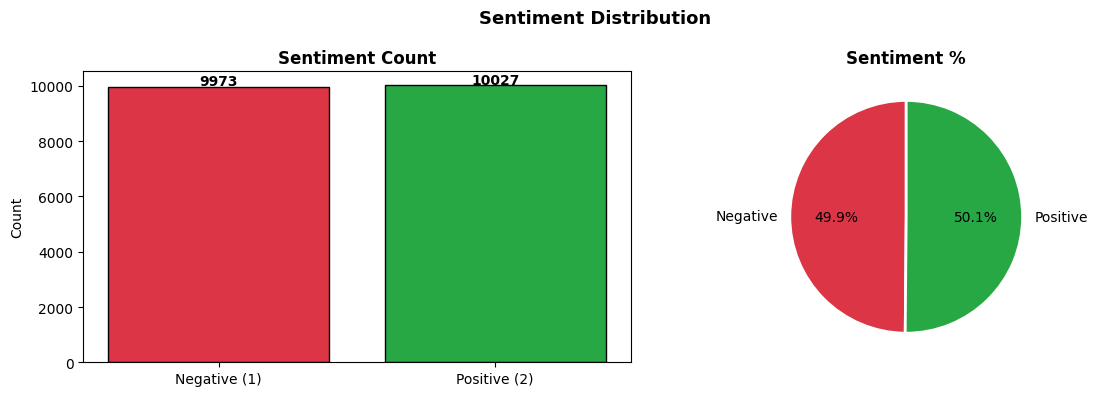

In [7]:
counts = train_df["sentiment"].value_counts().sort_index()
labels = {1:"Negative",2:"Positive"}
print(f"Sentiment counts:\n{counts}")
print(f"Positive %: {counts[2]/len(train_df)*100:.1f}%")
print(f"Negative %: {counts[1]/len(train_df)*100:.1f}%")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(["Negative (1)","Positive (2)"],counts.values,
            color=["#dc3545","#28a745"],edgecolor="black")
for i,v in enumerate(counts.values):
    axes[0].text(i,v+50,str(v),ha="center",fontweight="bold")
axes[0].set_title("Sentiment Count",fontweight="bold")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=["Negative","Positive"],
            colors=["#dc3545","#28a745"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Sentiment %",fontweight="bold")
plt.suptitle("Sentiment Distribution",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

### 1.3 Review Length Analysis

Review length stats by sentiment:
          review_length                                                   \
                  count   mean    std   min    25%    50%    75%     max   
sentiment                                                                  
1                9973.0  421.7  232.8  50.0  227.0  376.0  584.0  1003.0   
2               10027.0  386.1  232.4  50.0  189.0  331.0  542.0  1000.0   

          word_count                                             
               count  mean   std  min   25%   50%    75%    max  
sentiment                                                        
1             9973.0  77.3  42.1  9.0  42.0  70.0  107.0  201.0  
2            10027.0  70.6  41.9  9.0  35.0  61.0   98.0  209.0  


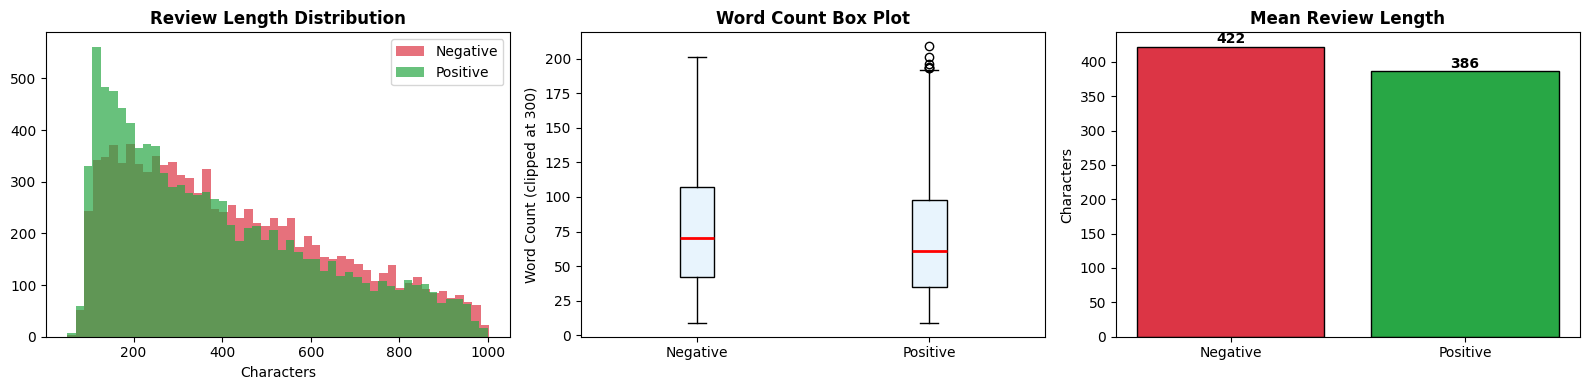

In [8]:
train_df["review_length"] = train_df["review"].apply(len)
train_df["word_count"]    = train_df["review"].apply(lambda x: len(x.split()))

print("Review length stats by sentiment:")
print(train_df.groupby("sentiment")[["review_length","word_count"]].describe().round(1))

fig, axes = plt.subplots(1,3,figsize=(16,4))

# Length histogram
for fb,col,lbl in zip([1,2],["#dc3545","#28a745"],["Negative","Positive"]):
    axes[0].hist(train_df[train_df["sentiment"]==fb]["review_length"],
                 bins=50, color=col, alpha=0.7, label=lbl)
axes[0].set_title("Review Length Distribution",fontweight="bold")
axes[0].set_xlabel("Characters"); axes[0].legend()

# Word count box
train_df["Sentiment Label"] = train_df["sentiment"].map({1:"Negative",2:"Positive"})
axes[1].boxplot(
    [train_df[train_df["sentiment"]==1]["word_count"].clip(0,300),
     train_df[train_df["sentiment"]==2]["word_count"].clip(0,300)],
    labels=["Negative","Positive"],
    patch_artist=True,
    boxprops=dict(facecolor="#e8f4fd"),
    medianprops=dict(color="red",linewidth=2)
)
axes[1].set_title("Word Count Box Plot",fontweight="bold")
axes[1].set_ylabel("Word Count (clipped at 300)")

# Mean length bar
mean_len = train_df.groupby("sentiment")["review_length"].mean()
axes[2].bar(["Negative","Positive"],mean_len.values,
            color=["#dc3545","#28a745"],edgecolor="black")
for i,v in enumerate(mean_len.values):
    axes[2].text(i,v+5,f"{v:.0f}",ha="center",fontweight="bold")
axes[2].set_title("Mean Review Length",fontweight="bold")
axes[2].set_ylabel("Characters")

plt.tight_layout(); plt.show()

### 1.4 Top Words by Sentiment

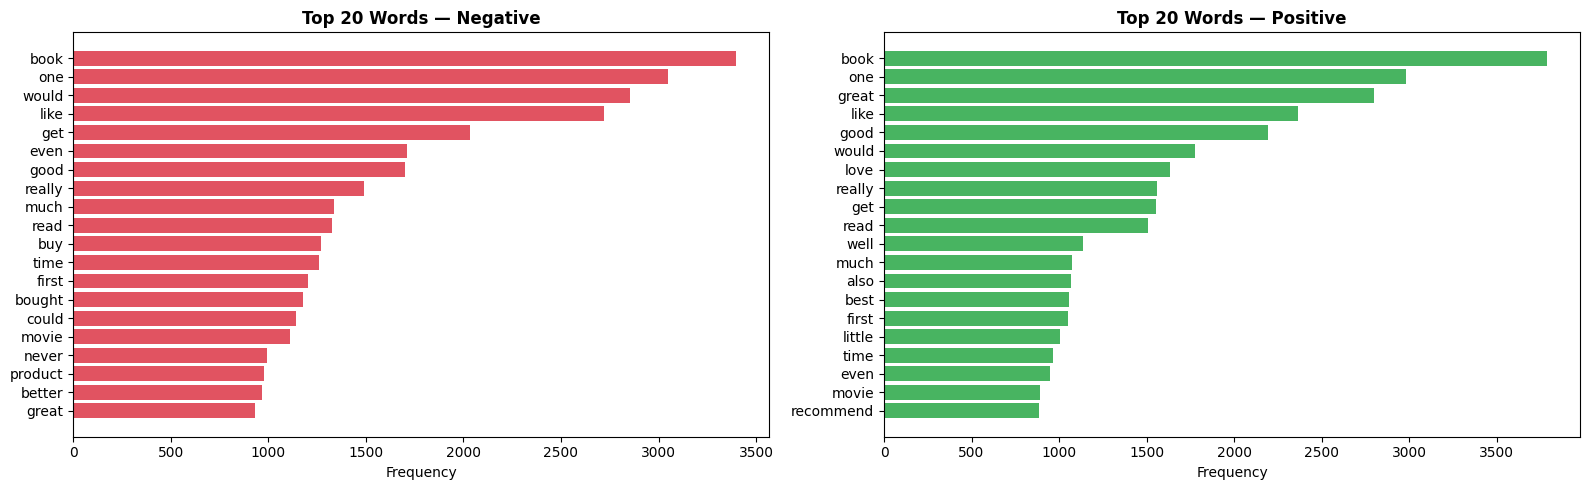

In [9]:
from collections import Counter

stop = set(stopwords.words("english"))

def top_words(texts, n=20):
    words = " ".join(texts).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop and len(w)>2]
    return Counter(words).most_common(n)

neg_words = top_words(train_df[train_df["sentiment"]==1]["review"])
pos_words = top_words(train_df[train_df["sentiment"]==2]["review"])

fig, axes = plt.subplots(1,2,figsize=(16,5))
for ax, words, col, title in zip(
    axes, [neg_words,pos_words], ["#dc3545","#28a745"],
    ["Top 20 Words — Negative","Top 20 Words — Positive"]
):
    wds, cts = zip(*words)
    ax.barh(wds[::-1], cts[::-1], color=col, alpha=0.85)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

### 1.5 Word Clouds

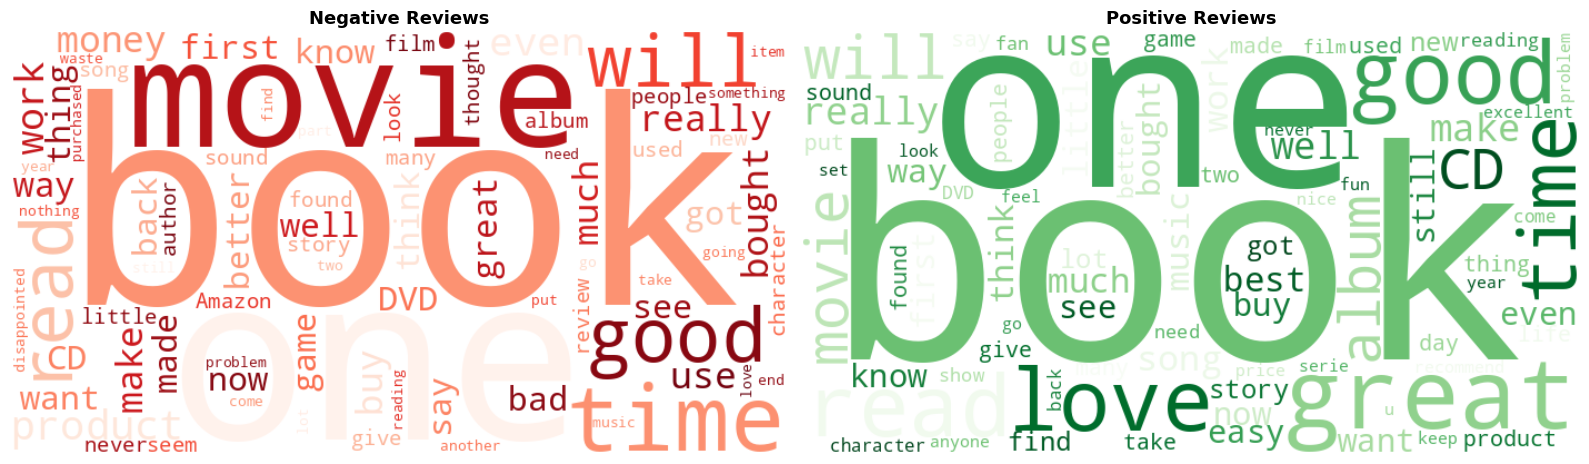

In [10]:
pos_text = " ".join(train_df[train_df["sentiment"]==2]["review"].astype(str))
neg_text = " ".join(train_df[train_df["sentiment"]==1]["review"].astype(str))

fig, axes = plt.subplots(1,2,figsize=(16,5))
for ax, text, cmap, title in zip(
    axes, [neg_text, pos_text], ["Reds","Greens"],
    ["Negative Reviews","Positive Reviews"]
):
    wc = WordCloud(background_color="white", max_words=80,
                   width=700, height=380, colormap=cmap)
    ax.imshow(wc.generate(text), interpolation="bilinear")
    ax.axis("off"); ax.set_title(title, fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

### 1.6 Title Analysis

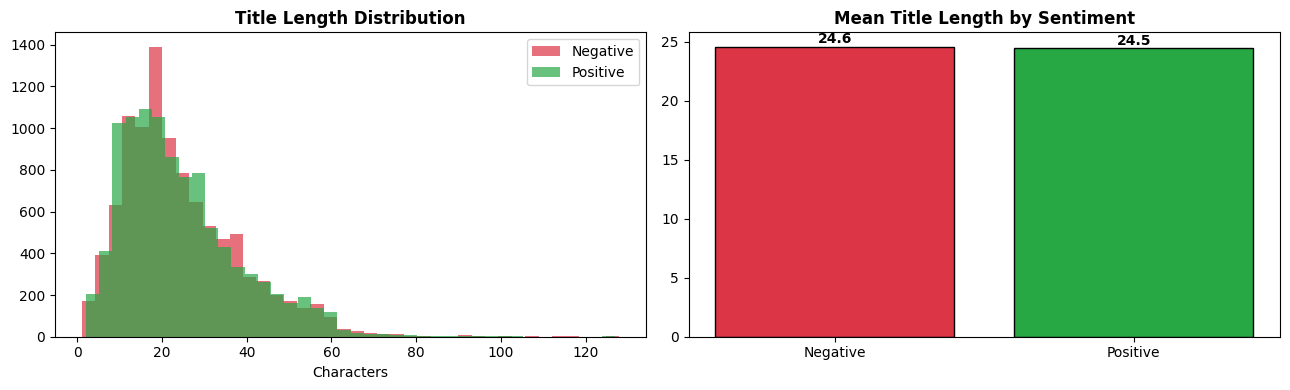

Top 5 most common titles:
title
Disappointed              50
Disappointing             48
Excellent                 27
Great                     19
Don't waste your money    19
Name: count, dtype: int64


In [11]:
train_df["title_length"] = train_df["title"].apply(len)

fig, axes = plt.subplots(1,2,figsize=(13,4))
for fb,col,lbl in zip([1,2],["#dc3545","#28a745"],["Negative","Positive"]):
    axes[0].hist(train_df[train_df["sentiment"]==fb]["title_length"],
                 bins=40, color=col, alpha=0.7, label=lbl)
axes[0].set_title("Title Length Distribution",fontweight="bold")
axes[0].set_xlabel("Characters"); axes[0].legend()

tl_mean = train_df.groupby("sentiment")["title_length"].mean()
axes[1].bar(["Negative","Positive"],tl_mean.values,
            color=["#dc3545","#28a745"],edgecolor="black")
for i,v in enumerate(tl_mean.values):
    axes[1].text(i,v+0.3,f"{v:.1f}",ha="center",fontweight="bold")
axes[1].set_title("Mean Title Length by Sentiment",fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 5 most common titles:")
print(train_df["title"].value_counts().head())

### 1.7 Feature Correlations

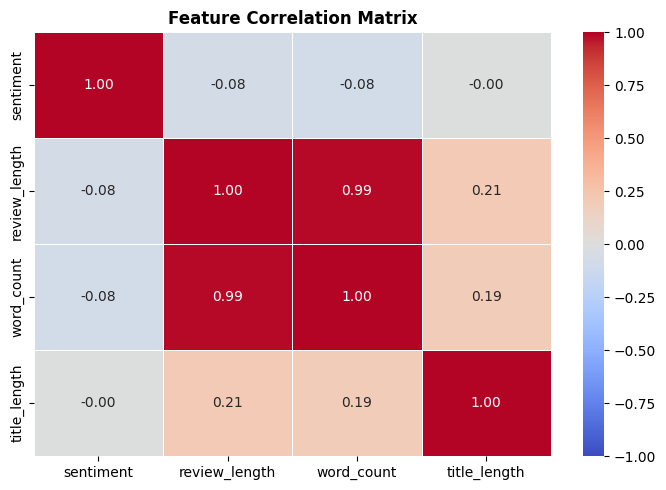

In [12]:
numeric_df = train_df[["sentiment","review_length","word_count","title_length"]]
plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix",fontweight="bold")
plt.tight_layout(); plt.show()

## 2. Preprocessing Pipeline

### Design decisions:
- Combine `title + review` → richer signal
- Contraction expansion before cleaning
- Negation prefixing: "not good" → `not_good`
- VADER lexicon scores as extra features
- Negative phrase blacklist feature
- TF-IDF trigrams (1,3) with 5000 features
- MinMaxScaler for SVM distance geometry
- SMOTE only if class imbalance detected


In [13]:
CONTRACTIONS = {
    "don't":"do not","doesn't":"does not","didn't":"did not",
    "isn't":"is not","wasn't":"was not","weren't":"were not",
    "can't":"can not","won't":"will not","wouldn't":"would not",
    "shouldn't":"should not","couldn't":"could not","haven't":"have not",
    "hasn't":"has not","hadn't":"had not","ain't":"is not",
    "it's":"it is","i'm":"i am","i've":"i have","i'll":"i will",
}

NEGATIVE_PHRASES = [
    "waste of money","waste of time","stopped working","does not work",
    "doesnt work","not working","broke after","stopped after",
    "complete waste","total waste","worst product","worst purchase",
    "not worth","not what i expected","very disappointed","highly disappointed",
    "poor quality","bad quality","not recommended","do not buy",
    "dont buy","return it","returned it","would not recommend",
    "stopped functioning","no longer works","gave up","useless","garbage",
    "awful","horrible","terrible","regret","frustrating","annoying",
    "defective","broken","malfunctioning","piece of junk","rip off",
    "false advertising","cheaply made","fell apart","broke immediately",
]

STOPWORDS_NLP = set(stopwords.words("english")) - {
    "not","no","never","nor","without","against","hardly","barely"
}

stemmer = PorterStemmer()

def expand_contractions(text):
    text = text.lower()
    for k,v in CONTRACTIONS.items():
        text = text.replace(k,v)
    return text

def build_tokens(text):
    text = expand_contractions(text)
    text = re.sub("[^a-zA-Z]"," ",text)
    words = text.lower().split()
    tokens = []
    negate = False
    for word in words:
        if word in {"not","no","never","nor","without"}:
            negate = True; continue
        stem = stemmer.stem(word)
        if word not in STOPWORDS_NLP:
            tokens.append(("not_"+stem) if negate else stem)
        negate = False
    return tokens

def count_neg_phrases(text):
    t = text.lower()
    return sum(1 for p in NEGATIVE_PHRASES if p in t)

# Test preprocessing
for txt in [
    "This product is absolutely amazing, I love it!",
    "Waste of money. Stopped working after a week.",
    "I can't believe how bad this is. Do not buy!",
]:
    toks = build_tokens(txt)
    sc   = vader.polarity_scores(txt)
    nph  = count_neg_phrases(txt)
    print(f"Text    : {txt[:60]}")
    print(f"Tokens  : {toks[:10]}")
    print(f"VADER   : {sc['compound']:.3f} | Neg phrases: {nph}")
    print()

Text    : This product is absolutely amazing, I love it!
Tokens  : ['product', 'absolut', 'amaz', 'love']
VADER   : 0.871 | Neg phrases: 0

Text    : Waste of money. Stopped working after a week.
Tokens  : ['wast', 'money', 'stop', 'work', 'week']
VADER   : -0.572 | Neg phrases: 2

Text    : I can't believe how bad this is. Do not buy!
Tokens  : ['not_believ', 'bad', 'not_buy']
VADER   : 0.484 | Neg phrases: 1



### 2.1 Build Corpus + Feature Engineering

In [14]:
def process_df(df):
    corpus          = []
    vader_compounds = []
    vader_pos_      = []
    vader_neg_      = []
    vader_neu_      = []
    phrase_counts   = []

    for i in range(len(df)):
        raw = df.iloc[i]["full_text"]
        corpus.append(" ".join(build_tokens(str(raw))))
        sc = vader.polarity_scores(str(raw))
        vader_compounds.append(sc["compound"])
        vader_pos_.append(sc["pos"])
        vader_neg_.append(sc["neg"])
        vader_neu_.append(sc["neu"])
        phrase_counts.append(count_neg_phrases(str(raw)))

    return corpus, np.column_stack([
        vader_compounds, vader_pos_, vader_neg_, vader_neu_, phrase_counts
    ])

print("Processing training data...")
train_corpus, train_extra = process_df(train_df)
print(f"  Done — {len(train_corpus)} documents")

print("Processing test data...")
test_corpus, test_extra = process_df(test_df)
print(f"  Done — {len(test_corpus)} documents")

print("\nSample tokens:")
for i in [0, 100, 500]:
    print(f"  [{i}] {train_corpus[i][:80]}")

Processing training data...
  Done — 20000 documents
Processing test data...
  Done — 5000 documents

Sample tokens:
  [0] expens junk product consist piec thin flexibl insul materi adhes back velcro whi
  [100] nice pick holder hold pick depend type pick prefer obvious thick pick mean less 
  [500] still work fine year tv sinc august cdn write june replac lamp still work fine m


### 2.2 TF-IDF Vectorisation

In [15]:
tfidf = TfidfVectorizer(
    max_features  = 5000,
    ngram_range   = (1, 3),
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = "unicode",
    analyzer      = "word",
)

X_train_tfidf = tfidf.fit_transform(train_corpus).toarray()
X_test_tfidf  = tfidf.transform(test_corpus).toarray()

# Combine TF-IDF + VADER + phrase features
X_train_comb = np.hstack([X_train_tfidf, train_extra])
X_test_comb  = np.hstack([X_test_tfidf,  test_extra])

y_train = train_df["sentiment"].values
y_test  = test_df["sentiment"].values

print(f"Feature matrix shape  : {X_train_comb.shape}")
print(f"  TF-IDF features     : {X_train_tfidf.shape[1]}")
print(f"  VADER + phrase feats: 5")
print(f"  Total               : {X_train_comb.shape[1]}")
print(f"\ny_train — 1(Neg): {(y_train==1).sum()} | 2(Pos): {(y_train==2).sum()}")
print(f"y_test  — 1(Neg): {(y_test==1).sum()}  | 2(Pos): {(y_test==2).sum()}")

Feature matrix shape  : (20000, 5005)
  TF-IDF features     : 5000
  VADER + phrase feats: 5
  Total               : 5005

y_train — 1(Neg): 9973 | 2(Pos): 10027
y_test  — 1(Neg): 2470  | 2(Pos): 2530


### 2.3 Scaling

In [16]:
scaler = MinMaxScaler()
X_train_scl = scaler.fit_transform(X_train_comb)
X_test_scl  = scaler.transform(X_test_comb)

print(f"Scaled — max: {X_train_scl.max():.4f} | min: {X_train_scl.min():.4f}")

Scaled — max: 1.0000 | min: 0.0000


### 2.4 Class Imbalance Check + SMOTE

Class counts: {1: np.int64(9973), 2: np.int64(10027)}
Imbalance ratio: 1.01:1

Dataset is balanced — SMOTE not required.


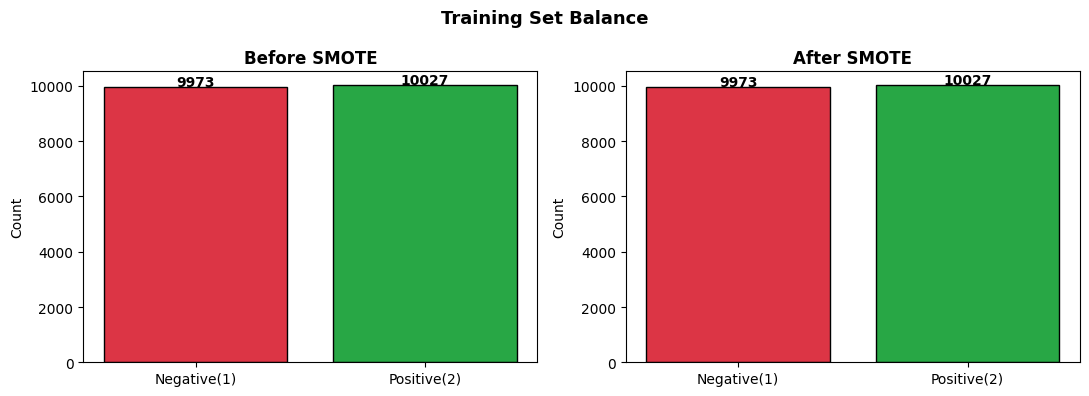

In [17]:
counts = pd.Series(y_train).value_counts().sort_index()
ratio  = counts.max() / counts.min()
print(f"Class counts: {dict(counts)}")
print(f"Imbalance ratio: {ratio:.2f}:1")

if ratio > 1.5:
    print("\nApplying SMOTE to balance training set...")
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train_scl, y_train)
    print(f"After SMOTE: {dict(pd.Series(y_train_res).value_counts().sort_index())}")
else:
    print("\nDataset is balanced — SMOTE not required.")
    X_train_res, y_train_res = X_train_scl, y_train

# Visualise before/after
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_res).value_counts().sort_index()

fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax,counts_,title in zip(axes,[before,after],["Before SMOTE","After SMOTE"]):
    ax.bar(["Negative(1)","Positive(2)"],counts_.values,
           color=["#dc3545","#28a745"],edgecolor="black")
    for i,v in enumerate(counts_.values):
        ax.text(i,v+30,str(v),ha="center",fontweight="bold")
    ax.set_title(title,fontweight="bold"); ax.set_ylabel("Count")
plt.suptitle("Training Set Balance",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

## 3. SVM + GridSearchCV

Grid: 4 C values × 3 kernels × 2 gamma = 24 combinations × 5-fold CV = **120 fits**
Scoring: **F1 macro** (handles potential class imbalance)

In [18]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "C": [0.1, 1, 10]
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = LinearSVC(random_state=42, class_weight="balanced"),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = "f1_macro",
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_res, y_train_res)

print(f"\nBest Params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_*100:.2f}%")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best Params : {'C': 0.1}
Best CV F1  : 87.99%


Top Parameter Combinations:
 param_C  mean_test_score  std_test_score
     0.1           0.8799          0.0026
     1.0           0.8513          0.0028
    10.0           0.8304          0.0040


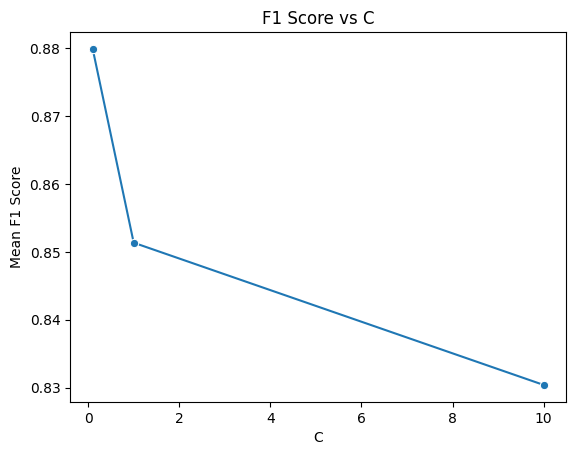

In [21]:
cv_results = pd.DataFrame(grid_search.cv_results_)

print("Top Parameter Combinations:")
print(cv_results[["param_C", "mean_test_score", "std_test_score"]]
      .sort_values("mean_test_score", ascending=False)
      .round(4)
      .to_string(index=False))

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=cv_results,
    x="param_C",
    y="mean_test_score",
    marker="o"
)

plt.title("F1 Score vs C")
plt.xlabel("C")
plt.ylabel("Mean F1 Score")
plt.show()

## 4. Train Best Model & Evaluate

In [23]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report

# Get best parameters from GridSearch
best_params = grid_search.best_params_
print(f"Training Best SVM: {best_params}")

# Base model (fast)
base_model = LinearSVC(**best_params, random_state=42, class_weight="balanced")

# Calibrated model (adds probability support)
model_svm = CalibratedClassifierCV(base_model)

# Train model
model_svm.fit(X_train_res, y_train_res)

# Predictions
y_pred = model_svm.predict(X_test_scl)
y_prob = model_svm.predict_proba(X_test_scl)[:, 1]  # probability of positive class

# Evaluation
print(f"\nTrain Accuracy : {model_svm.score(X_train_res, y_train_res)*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Training Best SVM: {'C': 0.1}

Train Accuracy : 94.08%
Test  Accuracy : 88.24%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      2470
    Positive       0.88      0.89      0.89      2530

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



KeyError: 'kernel'

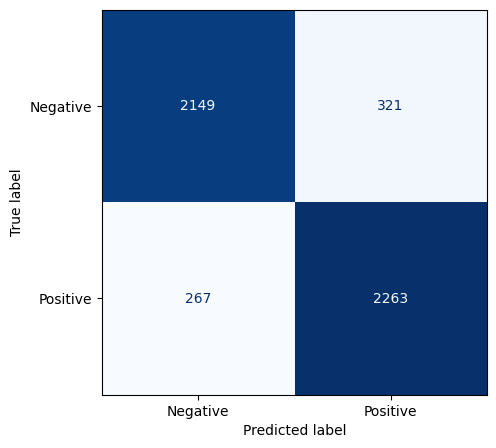

In [25]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=["Negative","Positive"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_params['kernel'].upper()} kernel",
             fontweight="bold")
for lbl,(r,c) in zip(["TN","FP","FN","TP"],[(0,0),(0,1),(1,0),(1,1)]):
    ax.text(c+0.5,r+0.72,lbl,ha="center",fontsize=9,
            color="white" if cm[r,c]>cm.max()*0.5 else "gray",
            transform=ax.transData)
plt.tight_layout(); plt.show()

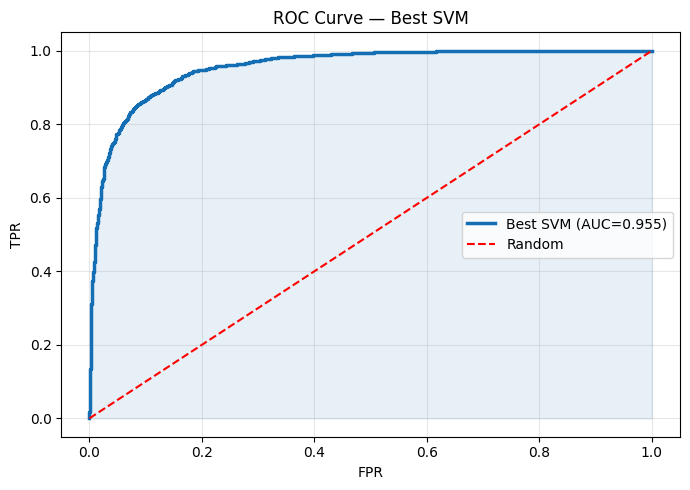

ROC-AUC: 0.9553


In [26]:
# Map classes: model.classes_ = [1,2], prob[:,1] = prob of class 2 (Positive)
y_test_bin = (y_test == 2).astype(int)   # 1=Positive, 0=Negative
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
auc_score   = roc_auc_score(y_test_bin, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#146EB4", lw=2.5,
         label=f"Best SVM (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"r--", label="Random")
plt.fill_between(fpr, tpr, alpha=0.1, color="#146EB4")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve — Best SVM"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"ROC-AUC: {auc_score:.4f}")

In [27]:
cv_scores = cross_val_score(model_svm, X_train_res, y_train_res,
                            cv=5, scoring="f1_macro")
print(f"CV F1 Macro Scores : {[round(s,4) for s in cv_scores]}")
print(f"CV Mean            : {cv_scores.mean()*100:.2f}%")
print(f"CV Std             : ±{cv_scores.std()*100:.2f}%")

CV F1 Macro Scores : [np.float64(0.8785), np.float64(0.883), np.float64(0.8772), np.float64(0.888), np.float64(0.8792)]
CV Mean            : 88.12%
CV Std             : ±0.39%


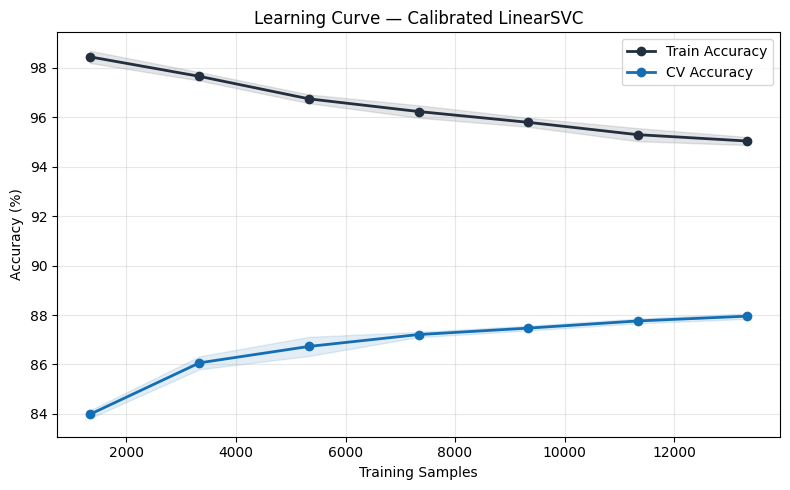

In [29]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_sc, val_sc = learning_curve(
    model_svm,
    X_train_res,
    y_train_res,
    cv=3,  # reduced from 5 → faster
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 7),
    n_jobs=-1
)

plt.figure(figsize=(8,5))

# Train accuracy
plt.plot(train_sizes, train_sc.mean(axis=1)*100, "o-",
         color="#232F3E", lw=2, label="Train Accuracy")

plt.fill_between(train_sizes,
    (train_sc.mean(axis=1)-train_sc.std(axis=1))*100,
    (train_sc.mean(axis=1)+train_sc.std(axis=1))*100,
    alpha=0.12, color="#232F3E")

# Validation accuracy
plt.plot(train_sizes, val_sc.mean(axis=1)*100, "o-",
         color="#146EB4", lw=2, label="CV Accuracy")

plt.fill_between(train_sizes,
    (val_sc.mean(axis=1)-val_sc.std(axis=1))*100,
    (val_sc.mean(axis=1)+val_sc.std(axis=1))*100,
    alpha=0.12, color="#146EB4")

plt.xlabel("Training Samples")
plt.ylabel("Accuracy (%)")
plt.title("Learning Curve — Calibrated LinearSVC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. (Optional) All Kernel Comparison

Kernel       Train%    Test%    ROC-AUC   Macro-F1
----------------------------------------------------
Linear       94.08%   88.24%     0.9553      88.2%


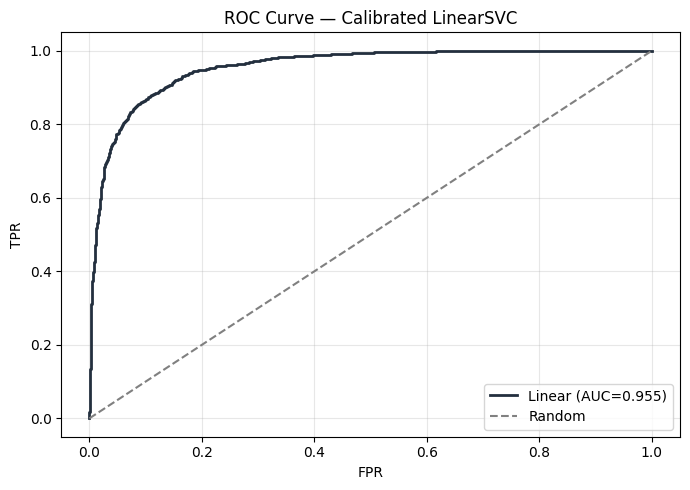

In [32]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Best parameter
C_best = best_params["C"]

# Store results
kernel_results = {}

# Use calibrated LinearSVC
variants = {
    "Linear": model_svm
}

# Header
print(f"{'Kernel':<10} {'Train%':>8} {'Test%':>8} {'ROC-AUC':>10} {'Macro-F1':>10}")
print("-"*52)

for name, mdl in variants.items():
    
    # Predictions
    yp  = mdl.predict(X_test_scl)
    ypr = mdl.predict_proba(X_test_scl)[:, 1]

    # Metrics
    rpt_v = classification_report(y_test, yp, output_dict=True)

    # ✅ FIX: specify positive class
    auc = roc_auc_score(y_test, ypr)
    f, t, _ = roc_curve(y_test, ypr, pos_label=2)

    kernel_results[name] = dict(fpr=f, tpr=t, auc=auc)

    print(f"{name:<10} {mdl.score(X_train_res, y_train_res)*100:>7.2f}% "
          f"{accuracy_score(y_test, yp)*100:>7.2f}% {auc:>10.4f} "
          f"{rpt_v['macro avg']['f1-score']*100:>9.1f}%")

# Plot ROC Curve
plt.figure(figsize=(7,5))

for (name, r), col in zip(kernel_results.items(), ["#232F3E"]):
    plt.plot(r["fpr"], r["tpr"],
             color=col, lw=2,
             label=f"{name} (AUC={r['auc']:.3f})")

plt.plot([0,1], [0,1], "gray", linestyle="--", label="Random")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve — Calibrated LinearSVC")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save All Models & Artefacts

In [33]:
pickle.dump(model_svm, open("Models/model_svm.pkl",           "wb"))
pickle.dump(tfidf,     open("Models/tfidf_vectorizer.pkl",    "wb"))
pickle.dump(scaler,    open("Models/scaler.pkl",              "wb"))

rpt_dict = classification_report(y_test, y_pred,
    target_names=["Negative","Positive"], output_dict=True)

y_test_bin = (y_test == 2).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
auc_score   = roc_auc_score(y_test_bin, y_prob)

train_counts = pd.Series(y_train).value_counts().sort_index()
res_counts   = pd.Series(y_train_res).value_counts().sort_index()

metrics_out = {
    "dataset":         "Amazon Product Reviews",
    "best_params":     best_params,
    "best_cv_f1":      float(grid_search.best_score_),
    "train_accuracy":  float(model_svm.score(X_train_res, y_train_res)),
    "test_accuracy":   float(accuracy_score(y_test, y_pred)),
    "roc_auc":         float(auc_score),
    "avg_precision":   float(average_precision_score(y_test_bin, y_prob)),
    "cv_f1_mean":      float(cv_scores.mean()),
    "cv_f1_std":       float(cv_scores.std()),
    "classification_report": rpt_dict,
    "confusion_matrix":      cm.tolist(),
    "roc_fpr":               fpr.tolist(),
    "roc_tpr":               tpr.tolist(),
    "dataset_info": {
        "train_size":    int(len(train_df)),
        "test_size":     int(len(test_df)),
        "total_size":    int(len(train_df)+len(test_df)),
        "neg_count":     int(train_counts.get(1,0)),
        "pos_count":     int(train_counts.get(2,0)),
        "smote_neg":     int(res_counts.get(1,0)),
        "smote_pos":     int(res_counts.get(2,0)),
        "test_neg":      int((y_test==1).sum()),
        "test_pos":      int((y_test==2).sum()),
    },
    "negative_phrases":       NEGATIVE_PHRASES,
    "contractions":           CONTRACTIONS,
    "prediction_threshold":   0.40,
    "label_map":              {"1":"Negative","2":"Positive"},
}

with open("Models/metrics.json","w") as f:
    json.dump(metrics_out, f, indent=2)

# Save processed sample for EDA tab
train_df.to_csv("Models/data_processed.csv", index=False)

print("Saved to Models/")
for fn in ["model_svm.pkl","tfidf_vectorizer.pkl","scaler.pkl",
           "metrics.json","data_processed.csv"]:
    size = os.path.getsize(f"Models/{fn}")/1024
    print(f"  {fn:<30} {size:>8.1f} KB")
print()
print("Run: streamlit run app.py")

Saved to Models/
  model_svm.pkl                     197.7 KB
  tfidf_vectorizer.pkl              180.2 KB
  scaler.pkl                        196.0 KB
  metrics.json                       41.8 KB
  data_processed.csv              17317.2 KB

Run: streamlit run app.py
